# MC 05 — Peak-Risk Stability & Stress Tests

Evaluate fold stability, horizon behavior, and M9W-2023 across classifiers.

In [1]:

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "configs" / "model_comparison.yaml"


In [2]:
import matplotlib.pyplot as plt
from src.ontario_peak_risk.model_comparison.io import load_config, load_model_reports
from src.ontario_peak_risk.model_comparison.metrics import (
    combine_group_metrics,
    peak_stability,
    m9w_peak_stress,
)
from src.ontario_peak_risk.model_comparison.plotting import m9w_bar_plot

config, project_root = load_config(CONFIG_PATH)
reports = load_model_reports(config, project_root, "peak_risk")
fold_table = combine_group_metrics(reports, "fold_metrics")
fsa_table = combine_group_metrics(reports, "fsa_metrics")
horizon_table = combine_group_metrics(reports, "horizon_metrics")

stability = peak_stability(fold_table, horizon_table)
m9w_2023 = m9w_peak_stress(fsa_table)

display(stability.sort_values("fold_pr_auc_range"))
display(m9w_2023.sort_values("pr_auc", ascending=False))


,model,fold_pr_auc_mean,fold_pr_auc_std,fold_pr_auc_range,horizon_pr_auc_slope,short_horizon_pr_auc_h01_h06,long_horizon_pr_auc_h19_h24
3,Random Forest Classifier,0.650551,0.022152,0.044305,-0.007502,0.736088,0.600645
0,HistGradientBoosting,0.653279,0.028750,0.057501,-0.009620,0.767241,0.591634
4,XGBoost Classifier,0.641663,0.029240,0.058481,-0.010639,0.769668,0.573700
1,LightGBM Classifier,0.629520,0.036332,0.072665,-0.010181,0.757015,0.570372
2,Logistic Regression,0.641471,0.102684,0.205369,0.000026,0.641391,0.641861


,model,family,precision,recall,f1,pr_auc,roc_auc,balanced_accuracy,brier_score,positive_rate_pct
3,Random Forest Classifier,Bagging,0.987990,0.172506,0.293726,0.927679,0.925991,0.585144,0.302187,51.404151
4,XGBoost Classifier,Gradient Boosting,0.983272,0.268872,0.422275,0.914292,0.910618,0.632017,0.324131,51.404151
1,LightGBM Classifier,Gradient Boosting,0.978930,0.271155,0.424678,0.907905,0.906145,0.632491,0.325402,51.404151
0,HistGradientBoosting,Gradient Boosting,0.990789,0.113782,0.204123,0.896261,0.893199,0.556332,NaN,51.404151
2,Logistic Regression,Baseline,0.915628,0.370853,0.527894,0.884445,0.912276,0.667352,NaN,51.404151


e:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\src\ontario_peak_risk\model_comparison\plotting.py:220: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


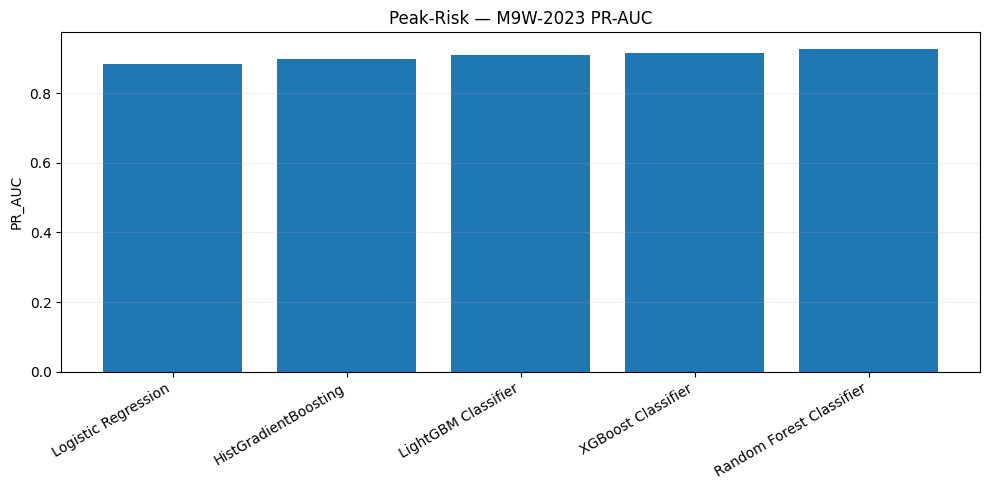

In [3]:
m9w_bar_plot(m9w_2023, "pr_auc", "Peak-Risk — M9W-2023 PR-AUC"); plt.show()

e:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\src\ontario_peak_risk\model_comparison\plotting.py:220: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


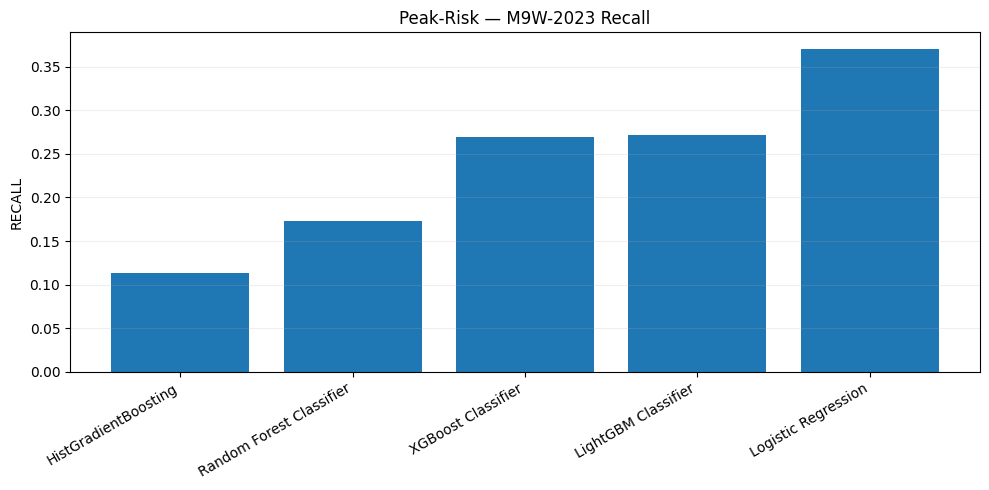

In [4]:
m9w_bar_plot(m9w_2023, "recall", "Peak-Risk — M9W-2023 Recall"); plt.show()